### 1. Specific Goal

The goal of this project is to analyze the urbanization of Doha, the capital city of Qatar, between 2016 and 2025 using satellite imagery. The main focus is to observe how the city has expanded over time.

Doha is located on the eastern coast of Qatar, along the Persian Gulf. It is one of the fastest-growing cities in the Middle East. To the west, the city is bordered by desert areas, which makes urban detection more challenging.

The goal of the analysis is to find how the city has grown, see how land use has changed, and check how much different areas have been developed.

In [63]:
import os

import rasterio
import numpy as np
from rasterio.plot import show
from rasterio.plot import show_hist
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import binary_erosion, binary_dilation

### 2. Data

Two satellite images of Doha and its surroundings were used: one taken on October 22, 2016, and the other on May 13, 2025. Both images were captured by the Sentinel-2 satellite.

Several spectral bands were downloaded, but this project focuses on the following:
- **B02** – Blue  
- **B04** – Red  
- **B08** – Near Infrared (NIR)

For color compositions, true color (B04, B03, B02) is used to vizualize the data.

In [64]:
path_img = "./2016/"

bands_2016 = []

for root, dirs, files in os.walk(path_img, topdown=False):
   for name in files:
      img = rasterio.open(os.path.join(path_img, name))
      bands_2016.append(img.read())

In [65]:
path_img = "./2025/"

bands_2025 = []

for root, dirs, files in os.walk(path_img, topdown=False):
   for name in files:
      img = rasterio.open(os.path.join(path_img, name))
      bands_2025.append(img.read())

In [66]:
bands_2016 = np.concatenate(bands_2016)
bands_2025 = np.concatenate(bands_2025)

Picture research

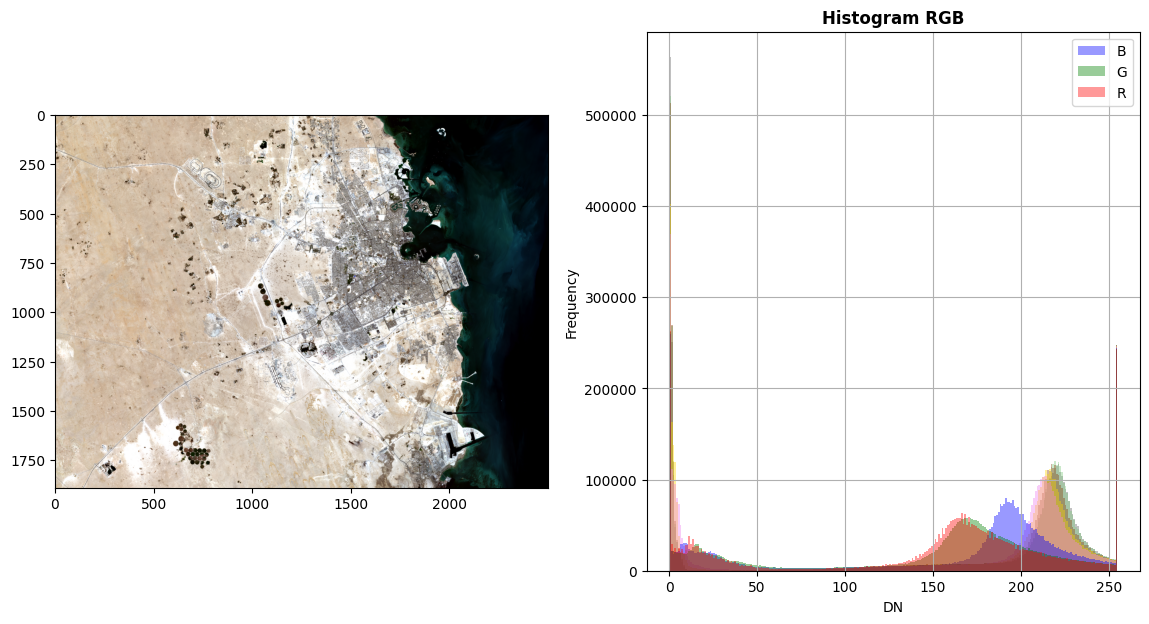

In [67]:
# 2016 high contrast
bands_8bit = []
for band in bands_2016[:8]:
    band = band.astype(np.float32)
    p1, p2 = np.percentile(band, (5,95))
    band = np.clip(band, p1, p2)
    band_8bit = (((band - p1))/(p2-p1))*255
    band_8bit = band_8bit.astype(np.uint8)
    bands_8bit.append(band_8bit)

bands_8bit_2016 = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2016[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2016, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

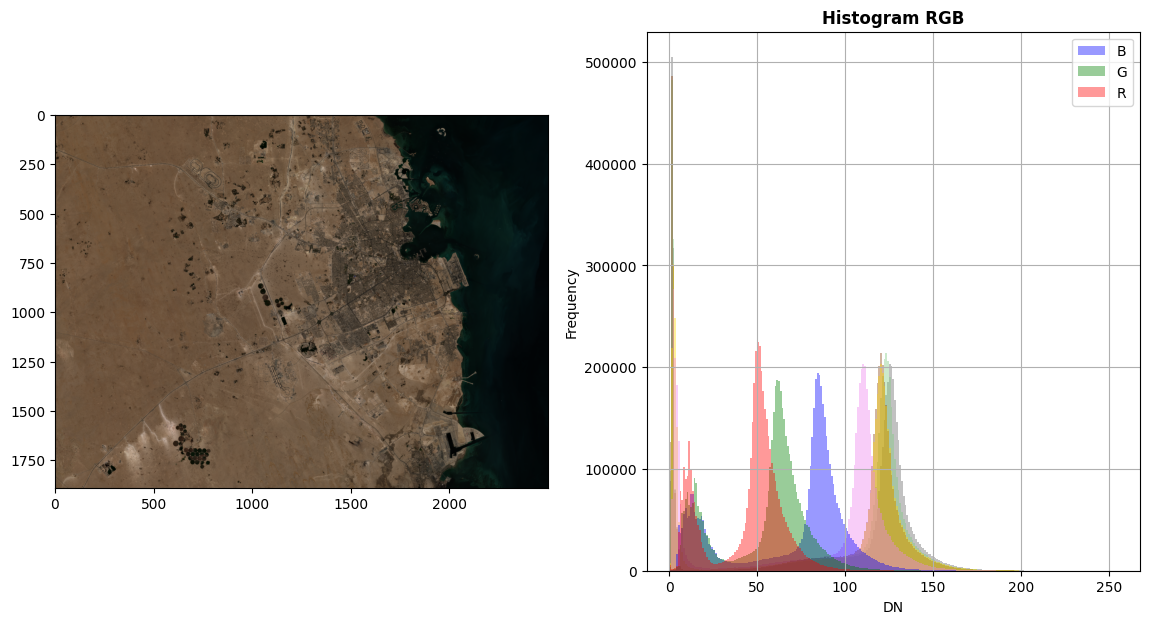

In [68]:
# 2016 normal

bands_8bit = []
for band in bands_2016[:8]:
    band = band.astype(np.float32)
    band = band/65535.0 * 255
    bands_8bit.append(band.astype(np.uint8))

bands_8bit_2016_N = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2016_N[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2016_N, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

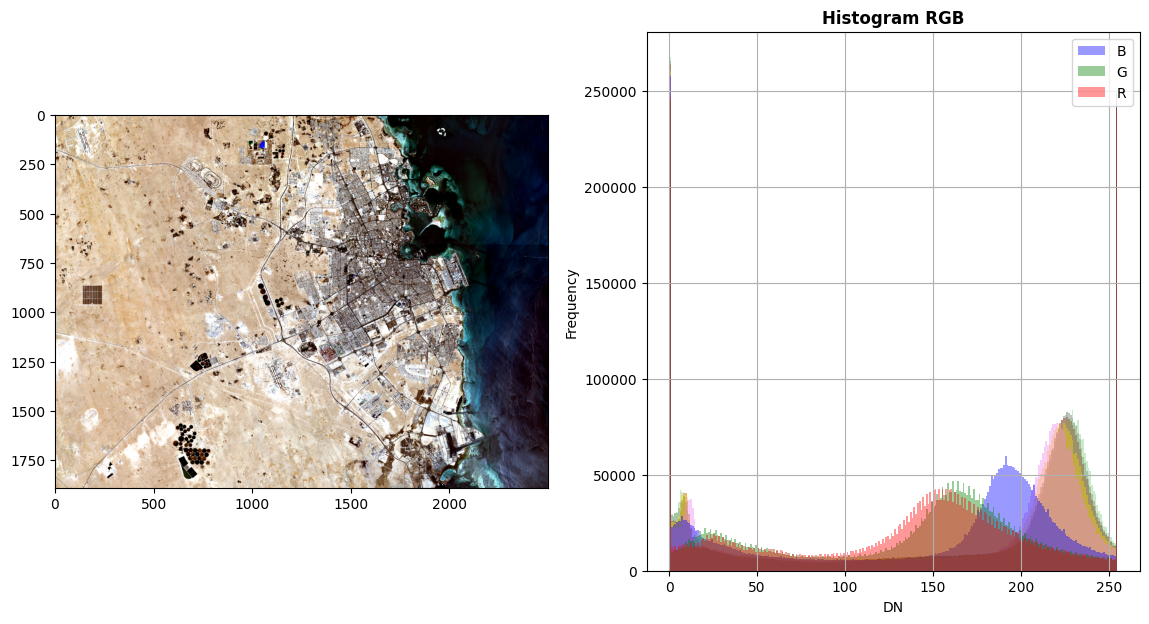

In [69]:
# 2025 high contrast
bands_8bit = []
for band in bands_2025[:8]:
    band = band.astype(np.float32)
    p1, p2 = np.percentile(band, (5,95))
    band = np.clip(band, p1, p2)
    band_8bit = (((band - p1))/(p2-p1))*255
    band_8bit = band_8bit.astype(np.uint8)
    bands_8bit.append(band_8bit)

bands_8bit_2025 = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2025[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2025, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

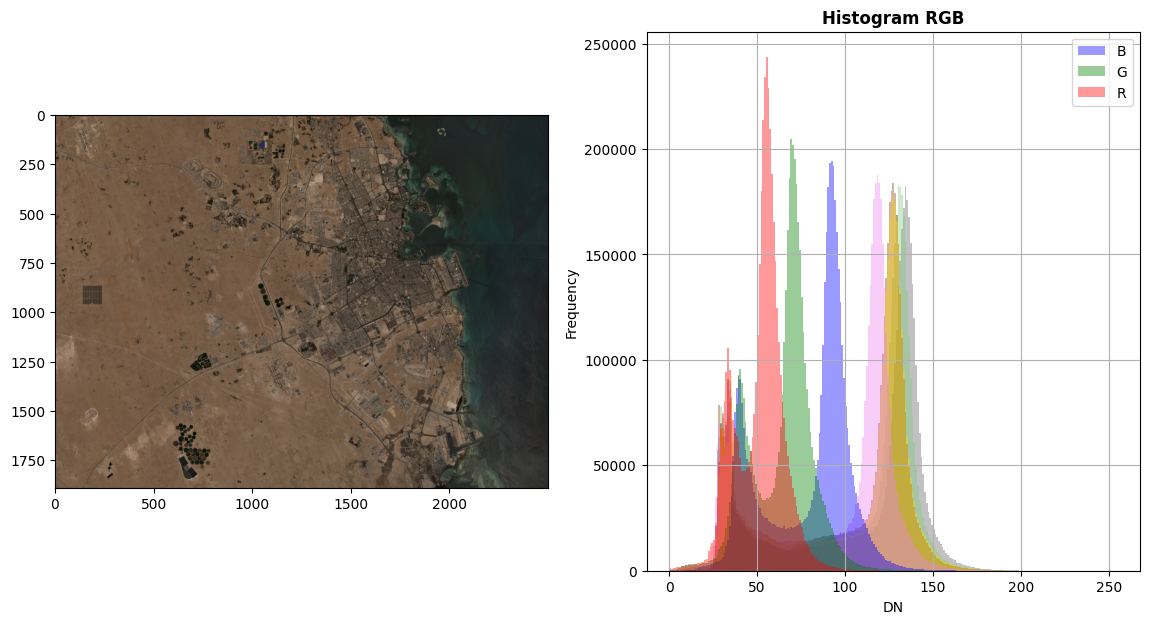

In [70]:
# 2025 normal

bands_8bit = []
for band in bands_2025[:8]:
    band = band.astype(np.float32)
    band = band/65535.0 * 255
    bands_8bit.append(band.astype(np.uint8))

bands_8bit_2025_N = np.stack(bands_8bit, axis=0)
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(bands_8bit_2025_N[(3,2,1), :, :], ax=axrgb)
show_hist(bands_8bit_2025_N, bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)
plt.show()

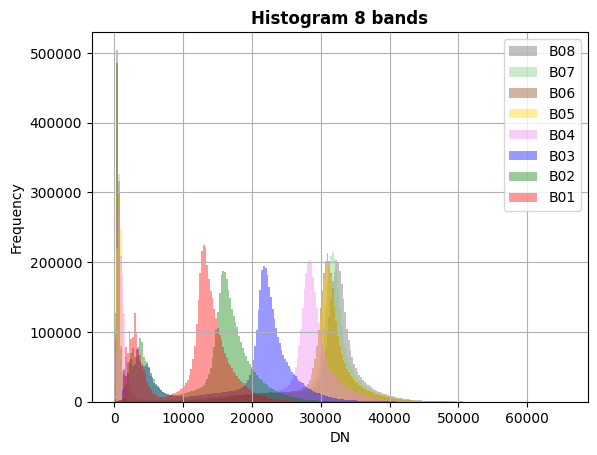

In [71]:
# Many low value pixels because the sea is very dark
show_hist(bands_2016[:8], bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram 8 bands', label = ['B01','B02','B03', 'B04', 'B05', 'B06', 'B07', 'B08'])

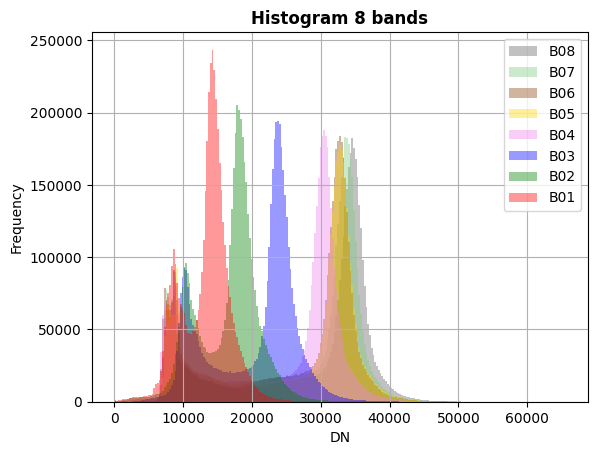

In [72]:
show_hist(bands_2025[:8], bins=255, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram 8 bands', label = ['B01','B02','B03', 'B04', 'B05', 'B06', 'B07', 'B08'])

### 3. Methods

- **Binarization** – converting image pixel values to only 0 and 1 to highlight specific features.  
- **Filtering** – modifying pixel values based on a threshold to reduce noise or enhance details.  
- **Morphological closing** – applying dilation followed by erosion to smooth the image and close small gaps.

Additionally, two indices were used:  
- **NDVI (Normalized Difference Vegetation Index)** – uses near-infrared and red bands to detect vegetation. In this project, it was used to identify water bodies.  
- **PISI (Perpendicular Index to Soil Index)** – uses near-infrared and blue bands and is effective for distinguishing urban areas from soil.

Separate urban area for year 2016:

In [73]:
# Good for water detection, bad for urban areas
ndvi_index_2016 = ((bands_2016[7].astype(np.float32) - bands_2016[3].astype(np.float32))/(bands_2016[7].astype(np.float32) + bands_2016[3].astype(np.float32))).astype(np.float32)

C:\Users\Janek\AppData\Local\Temp\ipykernel_33332\3689714120.py:2: RuntimeWarning: invalid value encountered in divide
  ndvi_index_2016 = ((bands_2016[7].astype(np.float32) - bands_2016[3].astype(np.float32))/(bands_2016[7].astype(np.float32) + bands_2016[3].astype(np.float32))).astype(np.float32)


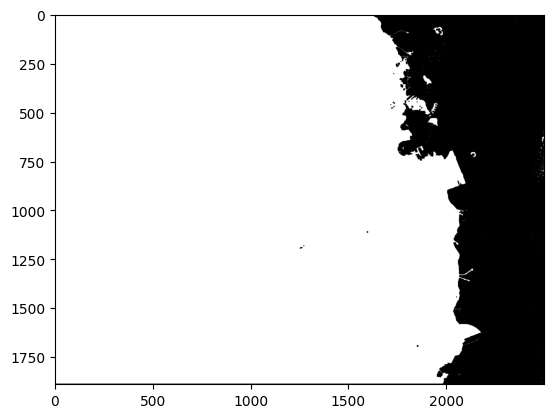

In [74]:
water = ndvi_index_2016.copy()

water = np.where(water < 0, 0, 1)

water = binary_dilation(water, iterations=1, structure=np.ones((5,5)))
water_mask = binary_erosion(water, iterations=1, structure=np.ones((5,5)))

plt.imshow(water_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

In [75]:
# Good to distinguish urban area (ofter > 0.1)
PISI_2016 = (bands_2016[1].astype('float32') + 1000.) / 65535.0*0.8192 - 0.5735*(bands_2016[7].astype('float32') + 1000.)/ 65535.0 + 0.0750

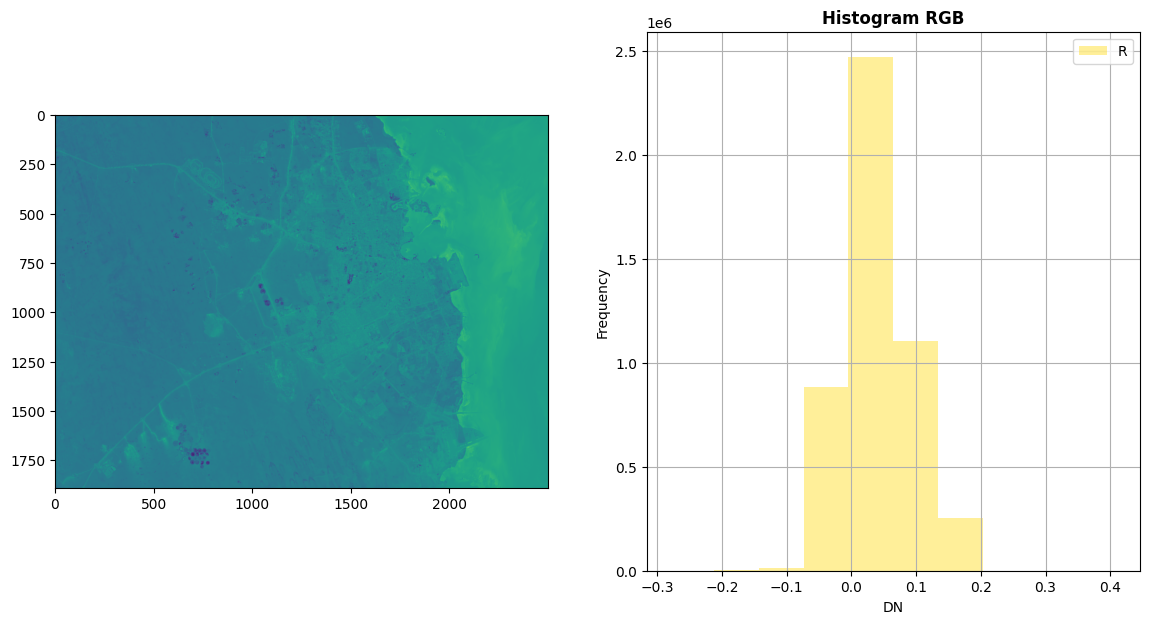

In [76]:
fig, (axrgb, axhist) = plt.subplots(1, 2, figsize=(14,7))
show(PISI_2016, ax=axrgb)
show_hist(PISI_2016, bins=10, lw=0.0, stacked = False, alpha = 0.4, histtype='stepfilled', title='Histogram RGB', label = ['R','G','B'], ax=axhist)

-0.28142178 0.4110198
0.4110198


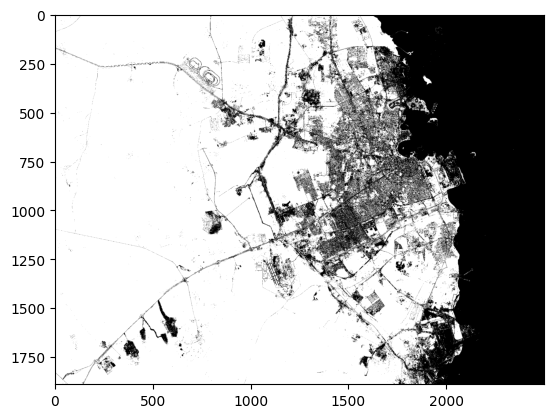

In [105]:
print(np.min(PISI_2016), np.max(PISI_2016))
min_threshold = 0.05
max_threshold = 0.54
print(np.max(PISI_2016))

urban_mask = np.where((PISI_2016 >= min_threshold) & (PISI_2016 <= max_threshold), 0, 1)

fig, axrgb = plt.subplots(1, 1)
axrgb.imshow(urban_mask, cmap='gray', vmin=0, vmax=1)
plt.show()

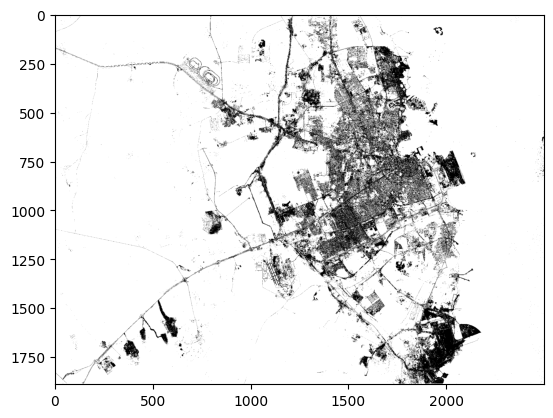

In [106]:
# city_2016 = 1 - (water_mask - urban_mask)
city_2016 = np.where((urban_mask == 0) & (water_mask == 1), 0, 1)
fig, axrgb = plt.subplots(1, 1)
axrgb.imshow(city_2016, cmap='gray', vmin=0, vmax=1)

2025

In [107]:
# SHOULD BE COMMENTED

# ndvi_index_2025 = ((bands_2025[7].astype(np.float32) - bands_2025[3].astype(np.float32))/(bands_2025[7].astype(np.float32) + bands_2025[3].astype(np.float32))).astype(np.float32)

# water = ndvi_index_2025.copy()

# #water = np.where(water < 0.02, 0, 1)

# min_threshold = -0.03
# max_threshold = 0.15
# #water = np.where((water >= min_threshold) & (water <= max_threshold), 0, 1)
# water = np.where(water < 0.06, 0, 1)

# water = binary_dilation(water, iterations=1, structure=np.ones((5,5)))
# water_mask = binary_erosion(water, iterations=1, structure=np.ones((5,5)))

# plt.imshow(water_mask, cmap='gray', vmin=0, vmax=1)
# plt.show()

0.53704983
-0.31327516


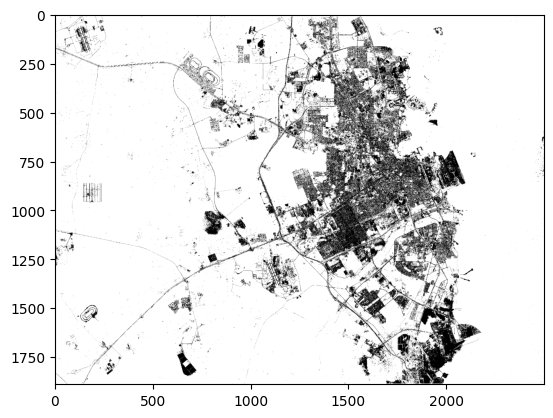

In [108]:
PISI_2025 = bands_2025[1].astype('float32') / 65535.0*0.8192 - 0.5735*bands_2025[7].astype('float32') / 65535.0 + 0.0750 

min_threshold = 0.05
max_threshold = 0.54
print(np.max(PISI_2025))
print(np.min(PISI_2025))
urban_mask = np.where((PISI_2025 >= min_threshold) & (PISI_2025 <= max_threshold), 0, 1)
# urban_mask = np.where((PISI_2025 >= 0.0) & (PISI_2025 <= 0.2), 0, 1)

fig, axrgb = plt.subplots(1, 1)
city_2025 = np.where((urban_mask == 0) & (water_mask == 1), 0, 1)
axrgb.imshow(city_2025, cmap='gray', vmin=0, vmax=1)
plt.show()

In [109]:
# SHOULD BE COMMENTED

# PISI_2025 = bands_2025[1].astype('float32') / 255.0*0.8192 - 0.5735*bands_2025[7].astype('float32') / 255.0 + 0.0750 

# min_threshold = -8
# max_threshold = 6
# print(np.max(PISI_2025))
# print(np.min(PISI_2025))
# urban_mask = np.where((PISI_2025 >= min_threshold) & (PISI_2025 <= max_threshold), 0, 1)
# # urban_mask = np.where((PISI_2025 >= 0.0) & (PISI_2025 <= 0.2), 1, 0)

# fig, axrgb = plt.subplots(1, 1)
# city_2025 = urban_mask
# axrgb.imshow(urban_mask, cmap='gray', vmin=0, vmax=1)
# plt.show()

### 4. Results

<Axes: >

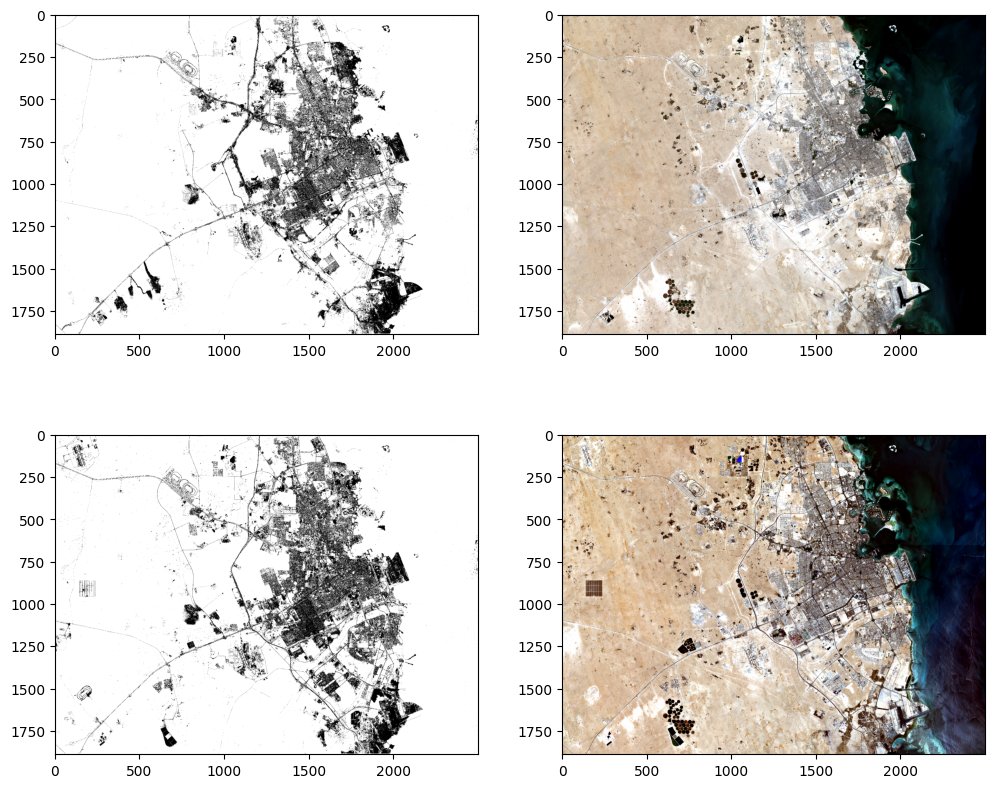

In [110]:
fig, ax = plt.subplots(2,2,figsize=(12,10))
ax[0][0].imshow(city_2016, cmap='gray', vmin=0, vmax=1)
show(bands_8bit_2016[(3,2,1), :, :], ax=ax[0][1])
# ax[0][1].imshow(bands_8bit_2016[(3,2,1), :, :], vmin=0, vmax=255)

ax[1][0].imshow(city_2025, cmap='gray', vmin=0, vmax=1)
show(bands_8bit_2025[(3,2,1), :, :], ax=ax[1][1])

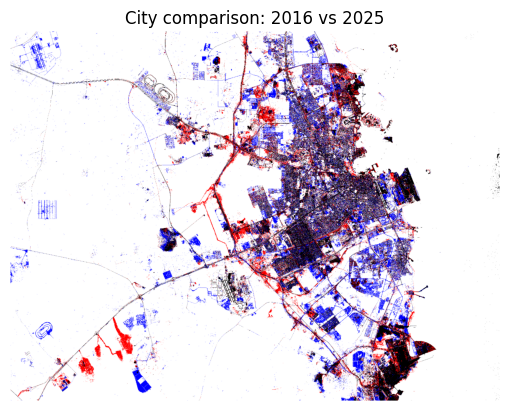

In [111]:
h, w = city_2016.shape
comparison = np.zeros((h, w, 3), dtype=np.uint8)

both_city = (city_2016 == 1) & (city_2025 == 1)
only_2016 = (city_2016 == 0) & (city_2025 == 1)
only_2025 = (city_2016 == 1) & (city_2025 == 0)
neither = (city_2016 == 0) & (city_2025 == 0)

comparison[both_city]   = [255, 255, 255] 
comparison[only_2016]   = [255, 0, 0]     
comparison[only_2025]   = [0, 0, 255]     
comparison[neither]     = [0, 0, 0]      

plt.imshow(comparison, vmin=0, vmax=255)
plt.title("City comparison: 2016 vs 2025")
plt.axis('off')
plt.show()

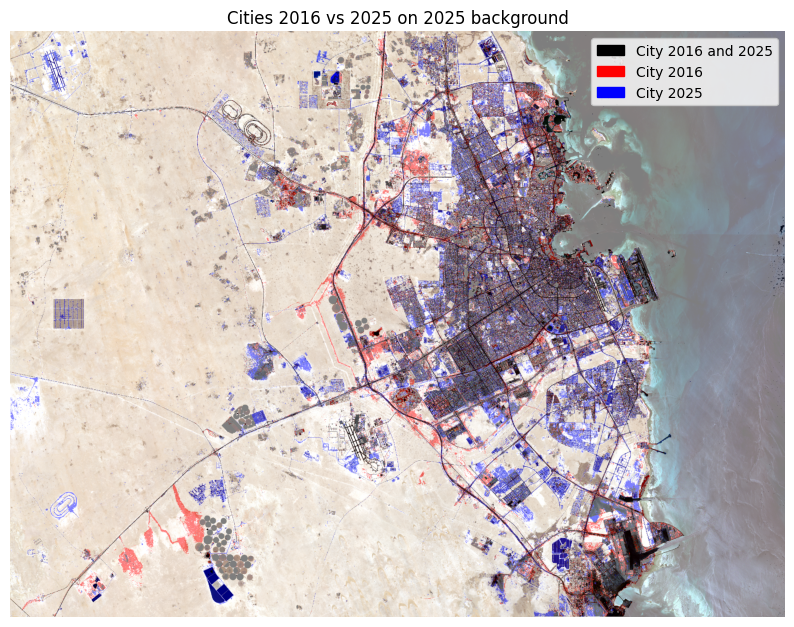

In [112]:
rgb = np.transpose(bands_8bit_2025[(3,2,1), :, :], (1, 2, 0)) 
mask_overlay = comparison

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(rgb)

ax.imshow(mask_overlay, alpha=0.5)

ax.set_title("Cities 2016 vs 2025 on 2025 background")
legend_patches = [
    mpatches.Patch(color='black', label='City 2016 and 2025'),
    mpatches.Patch(color='red', label='City 2016'),
    mpatches.Patch(color='blue', label='City 2025'),
]

ax.legend(handles=legend_patches, loc='upper right', frameon=True, fontsize=10)
ax.axis('off')
plt.show()

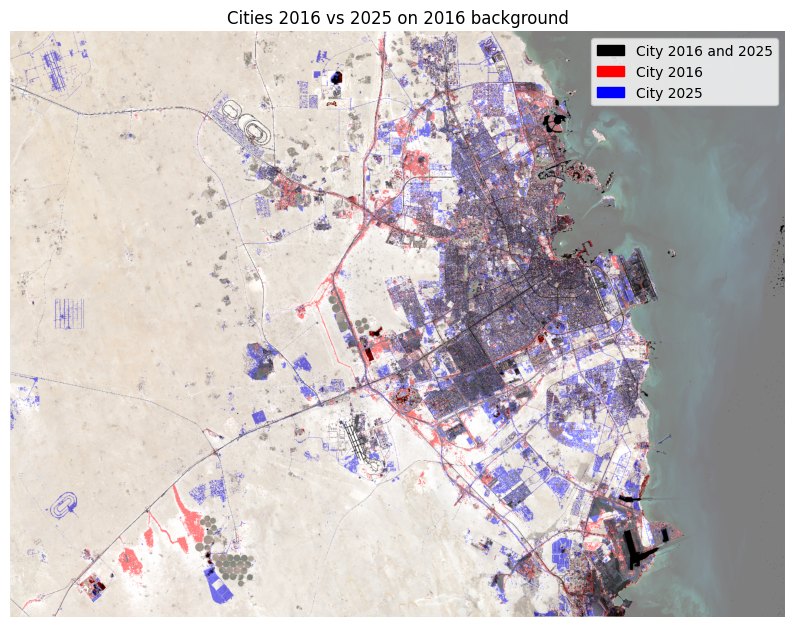

In [113]:
rgb = np.transpose(bands_8bit_2016[(3,2,1), :, :], (1, 2, 0)) 
mask_overlay = comparison

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(rgb)

ax.imshow(mask_overlay, alpha=0.5)

ax.set_title("Cities 2016 vs 2025 on 2016 background")
legend_patches = [
    mpatches.Patch(color='black', label='City 2016 and 2025'),
    mpatches.Patch(color='red', label='City 2016'),
    mpatches.Patch(color='blue', label='City 2025'),
]

ax.legend(handles=legend_patches, loc='upper right', frameon=True, fontsize=10)
ax.axis('off')
plt.show()

Calculating area

In [114]:
urbanization_percent_2016 = (city_2016 == 0).sum()/city_2016.size * 100
urbanization_percent_2025 = (city_2025 == 0).sum()/city_2025.size * 100

print(f"Urbanization percent in 2016: {urbanization_percent_2016}")
print(f"Urbanization percent in 2025: {urbanization_percent_2025}")

Urbanization percent in 2016: 10.577575436739016
Urbanization percent in 2025: 12.139036527263102


### 5. Conclusions

- Comparing Sentinel-2 data from 2016 and 2025 shows a visible shift in band values (by approximately 1000), which needs to be accounted for during analysis.

- Converting 16-bit images to 8-bit can be done in different ways, each highlighting different details of the image.

- The NDVI index works well for detecting water, but for identifying urban areas, other indices such as PISI are more effective.

- However, the PISI index is not perfect — it may mistakenly classify water, agricultural fields, or dirt roads as urban areas.

- Calculating and comparing the urban area size is not straightforward. The results depend heavily on the threshold used during classification, which can cause the estimated area to increase or decrease.

- Thresholds are subjective. Using the same value on two similar images can produce different results.